In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)

In [2]:
patients = pd.read_csv("patients.csv")
admissions = pd.read_csv("admissions.csv")
icustays = pd.read_csv("icustays.csv")
d_items = pd.read_csv("d_items.csv")
chartevents = pd.read_csv("chartevents.csv")

In [3]:
print("patients:", patients.shape)
print("admissions:", admissions.shape)
print("icustays:", icustays.shape)
print("d_items:", d_items.shape)
print("chartevents:", chartevents.shape)

patients: (100, 6)
admissions: (275, 16)
icustays: (140, 8)
d_items: (4014, 9)
chartevents: (668862, 11)


In [4]:
print("patients columns:\n", patients.columns.tolist(), "\n")
print("admissions columns:\n", admissions.columns.tolist(), "\n")
print("icustays columns:\n", icustays.columns.tolist(), "\n")
print("d_items columns:\n", d_items.columns.tolist(), "\n")
print("chartevents columns:\n", chartevents.columns.tolist())

patients columns:
 ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod'] 

admissions columns:
 ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag'] 

icustays columns:
 ['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los'] 

d_items columns:
 ['itemid', 'label', 'abbreviation', 'linksto', 'category', 'unitname', 'param_type', 'lownormalvalue', 'highnormalvalue'] 

chartevents columns:
 ['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'charttime', 'storetime', 'itemid', 'value', 'valuenum', 'valueuom', 'warning']


#  Merge core tables

In [5]:
df = icustays.merge(patients, on="subject_id", how="left")
df = df.merge(admissions, on=["subject_id", "hadm_id"], how="left")

print("Merged shape:", df.shape)
df.head()

Merged shape: (140, 27)


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dod,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512,F,83,2154,2014 - 2016,NaN,2154-04-24 03:15:00,2154-05-03 14:00:00,NaN,SURGICAL SAME DAY ADMISSION,P898NM,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,ENGLISH,DIVORCED,WHITE,NaN,NaN,0
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662,F,63,2169,2014 - 2016,NaN,2169-01-15 04:04:00,2169-01-24 17:20:00,NaN,OBSERVATION ADMIT,P898NM,EMERGENCY ROOM,HOME HEALTH CARE,Other,?,MARRIED,HISPANIC/LATINO - SALVADORAN,2169-01-14 23:26:00,2169-01-15 04:56:00,0
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685,F,63,2169,2014 - 2016,NaN,2170-02-24 00:00:00,2170-02-25 15:00:00,NaN,SURGICAL SAME DAY ADMISSION,P898NM,PHYSICIAN REFERRAL,HOME,Other,?,MARRIED,HISPANIC/LATINO - SALVADORAN,NaN,NaN,0
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725,F,91,2175,2014 - 2016,NaN,2176-11-25 21:28:00,2176-12-03 15:24:00,NaN,EW EMER.,P450WM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,ENGLISH,WIDOWED,BLACK/AFRICAN AMERICAN,2176-11-25 18:34:00,2176-11-25 23:51:00,0
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106,M,56,2150,2014 - 2016,NaN,2150-06-03 20:12:00,2150-06-07 15:05:00,NaN,EW EMER.,P80QIV,PACU,SKILLED NURSING FACILITY,Other,ENGLISH,SINGLE,WHITE,NaN,NaN,0


In [7]:
datetime_cols = ["intime", "outtime", "admittime", "dischtime", "deathtime", "dod"]

for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

In [8]:
df["los"] = pd.to_numeric(df["los"], errors="coerce")
df["long_icu_stay"] = (df["los"] >= 3).astype(int)

df[["stay_id", "los", "long_icu_stay"]].head()

,stay_id,los,long_icu_stay
0,31269608,7.702512,1
1,37509585,5.452662,1
2,32554129,0.872685,0
3,31338022,3.766725,1
4,32145159,1.037106,0


# Explore d_items for vital signs

In [9]:
vital_keywords = [
    "heart rate",
    "respiratory rate",
    "o2 saturation",
    "oxygen saturation",
    "temperature",
    "systolic blood pressure",
    "diastolic blood pressure",
    "mean arterial pressure"
]

mask = d_items["label"].astype(str).str.lower().apply(
    lambda x: any(keyword in x for keyword in vital_keywords)
)

candidate_items = d_items.loc[mask, ["itemid", "label", "category", "unitname"]].drop_duplicates()
candidate_items.sort_values("label").head(50)

,itemid,label,category,unitname
2451,226861,ART %O2 saturation (PA Line),PA Line Insertion,%
1976,220227,Arterial O2 Saturation,Labs,%
2578,226329,Blood Temperature CCO (C),Routine Vital Signs,°C
2397,229236,Cerebral Temperature (C),Hemodynamics,°C
415,224674,Changes in Temperature,Toxicology,NaN
2577,220045,Heart Rate,Routine Vital Signs,bpm
2054,220047,Heart Rate Alarm - Low,Alarms,bpm
2063,220046,Heart rate Alarm - High,Alarms,bpm
2069,223769,O2 Saturation Pulseoxymetry Alarm - High,Alarms,%
2067,223770,O2 Saturation Pulseoxymetry Alarm - Low,Alarms,%


# Choose common ICU vital item IDs

In [10]:
vital_map = {
    "heart_rate": 220045,
    "sbp": 220179,
    "dbp": 220180,
    "mbp": 220181,
    "resp_rate": 220210,
    "temperature_c": 223762,
    "spo2": 220277
}

pd.DataFrame(list(vital_map.items()), columns=["feature", "itemid"])

,feature,itemid
0,heart_rate,220045
1,sbp,220179
2,dbp,220180
3,mbp,220181
4,resp_rate,220210
5,temperature_c,223762
6,spo2,220277


In [11]:
selected_itemids = list(vital_map.values())

vitals = chartevents[chartevents["itemid"].isin(selected_itemids)].copy()
vitals["valuenum"] = pd.to_numeric(vitals["valuenum"], errors="coerce")
vitals = vitals.dropna(subset=["stay_id", "valuenum"])

print(vitals.shape)
vitals.head()

(66795, 11)


,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
37,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220210,19,19.0,insp/min,0.0
48,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,223762,37,37.0,°C,0.0
69,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220045,80,80.0,bpm,0.0
92,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220277,95,95.0,%,0.0
102,10005817,20626031,32604416,6770.0,2132-12-16 01:00:00,2132-12-16 01:04:00,220045,82,82.0,bpm,0.0


#  Keep first 24 hours of ICU measurements

In [12]:
vitals["charttime"] = pd.to_datetime(vitals["charttime"], errors="coerce")

stay_times = icustays[["stay_id", "intime"]].copy()
stay_times["intime"] = pd.to_datetime(stay_times["intime"], errors="coerce")

vitals = vitals.merge(stay_times, on="stay_id", how="left")
vitals["hours_from_icu_intime"] = (vitals["charttime"] - vitals["intime"]).dt.total_seconds() / 3600

vitals_24h = vitals[(vitals["hours_from_icu_intime"] >= 0) & (vitals["hours_from_icu_intime"] <= 24)].copy()

print(vitals_24h.shape)
vitals_24h.head()

(18681, 13)


,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning,intime,hours_from_icu_intime
0,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220210,19,19.0,insp/min,0.0,2132-12-15 09:29:01,14.516389
1,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,223762,37,37.0,°C,0.0,2132-12-15 09:29:01,14.516389
2,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220045,80,80.0,bpm,0.0,2132-12-15 09:29:01,14.516389
3,10005817,20626031,32604416,6770.0,2132-12-16 00:00:00,2132-12-16 00:02:00,220277,95,95.0,%,0.0,2132-12-15 09:29:01,14.516389
4,10005817,20626031,32604416,6770.0,2132-12-16 01:00:00,2132-12-16 01:04:00,220045,82,82.0,bpm,0.0,2132-12-15 09:29:01,15.516389


In [13]:
agg = (
    vitals_24h.groupby(["stay_id", "itemid"])["valuenum"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

agg["feature_name"] = agg["itemid"].map({v: k for k, v in vital_map.items()})

agg.head()

,stay_id,itemid,mean,min,max,feature_name
0,30057454,220045,108.533333,100.0,114.0,heart_rate
1,30057454,220179,79.333333,58.0,91.0,sbp
2,30057454,220180,54.666667,47.0,59.0,dbp
3,30057454,220181,60.333333,50.0,66.0,mbp
4,30057454,220210,18.266667,13.0,25.0,resp_rate


# Pivot vitals into wide format

In [14]:
vitals_wide = agg.pivot_table(
    index="stay_id",
    columns="feature_name",
    values=["mean", "min", "max"]
)

vitals_wide.columns = [f"{stat}_{feature}" for stat, feature in vitals_wide.columns]
vitals_wide = vitals_wide.reset_index()

print(vitals_wide.shape)
vitals_wide.head()

(140, 22)


,stay_id,max_dbp,max_heart_rate,max_mbp,max_resp_rate,max_sbp,max_spo2,max_temperature_c,mean_dbp,mean_heart_rate,mean_mbp,mean_resp_rate,mean_sbp,mean_spo2,mean_temperature_c,min_dbp,min_heart_rate,min_mbp,min_resp_rate,min_sbp,min_spo2,min_temperature_c
0,30057454,59.0,114.0,66.0,25.0,91.0,96.0,NaN,54.666667,108.533333,60.333333,18.266667,79.333333,92.366667,NaN,47.0,100.0,50.0,13.0,58.0,89.0,NaN
1,30101877,86.0,123.0,100.0,25.0,166.0,100.0,NaN,69.750000,94.875000,85.625000,20.541667,137.916667,100.000000,NaN,49.0,79.0,63.0,16.0,102.0,100.0,NaN
2,30425410,88.0,113.0,101.0,29.0,145.0,100.0,NaN,69.440000,95.576923,79.680000,19.307692,115.360000,99.259259,NaN,41.0,77.0,54.0,14.0,90.0,97.0,NaN
3,30458995,88.0,92.0,91.0,24.0,157.0,99.0,NaN,65.333333,81.720000,79.083333,17.600000,129.833333,97.360000,NaN,45.0,60.0,65.0,14.0,110.0,89.0,NaN
4,30585761,59.0,81.0,80.0,24.0,139.0,98.0,NaN,59.000000,70.958333,80.000000,19.375000,139.000000,95.181818,NaN,59.0,60.0,80.0,10.0,139.0,90.0,NaN


In [15]:
model_df = df.merge(vitals_wide, on="stay_id", how="left")
print("Model df shape:", model_df.shape)
model_df.head()

Model df shape: (140, 49)


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,gender,anchor_age,anchor_year,anchor_year_group,dod,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,long_icu_stay,max_dbp,max_heart_rate,max_mbp,max_resp_rate,max_sbp,max_spo2,max_temperature_c,mean_dbp,mean_heart_rate,mean_mbp,mean_resp_rate,mean_sbp,mean_spo2,mean_temperature_c,min_dbp,min_heart_rate,min_mbp,min_resp_rate,min_sbp,min_spo2,min_temperature_c
0,10018328,23786647,31269608,Neuro Stepdown,Neuro Stepdown,2154-04-24 23:03:44,2154-05-02 15:55:21,7.702512,F,83,2154,2014 - 2016,NaT,2154-04-24 03:15:00,2154-05-03 14:00:00,NaT,SURGICAL SAME DAY ADMISSION,P898NM,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,ENGLISH,DIVORCED,WHITE,NaN,NaN,0,1,68.0,93.0,83.0,26.0,136.0,100.0,NaN,54.642857,76.040000,73.500000,20.560000,115.857143,95.920000,NaN,49.0,65.0,68.0,13.0,108.0,91.0,NaN
1,10020187,24104168,37509585,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,2169-01-15 04:56:00,2169-01-20 15:47:50,5.452662,F,63,2169,2014 - 2016,NaT,2169-01-15 04:04:00,2169-01-24 17:20:00,NaT,OBSERVATION ADMIT,P898NM,EMERGENCY ROOM,HOME HEALTH CARE,Other,?,MARRIED,HISPANIC/LATINO - SALVADORAN,2169-01-14 23:26:00,2169-01-15 04:56:00,0,1,78.0,92.0,86.0,21.0,130.0,98.0,NaN,68.857143,74.880000,79.714286,16.560000,117.142857,96.160000,NaN,58.0,60.0,72.0,13.0,108.0,93.0,NaN
2,10020187,26842957,32554129,Neuro Intermediate,Neuro Intermediate,2170-02-24 18:18:46,2170-02-25 15:15:26,0.872685,F,63,2169,2014 - 2016,NaT,2170-02-24 00:00:00,2170-02-25 15:00:00,NaT,SURGICAL SAME DAY ADMISSION,P898NM,PHYSICIAN REFERRAL,HOME,Other,?,MARRIED,HISPANIC/LATINO - SALVADORAN,NaN,NaN,0,0,102.0,78.0,107.0,18.0,128.0,100.0,NaN,81.000000,62.600000,93.400000,14.611111,120.000000,95.562500,NaN,71.0,55.0,85.0,9.0,112.0,94.0,NaN
3,10012853,27882036,31338022,Trauma SICU (TSICU),Trauma SICU (TSICU),2176-11-26 02:34:49,2176-11-29 20:58:54,3.766725,F,91,2175,2014 - 2016,NaT,2176-11-25 21:28:00,2176-12-03 15:24:00,NaT,EW EMER.,P450WM,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,ENGLISH,WIDOWED,BLACK/AFRICAN AMERICAN,2176-11-25 18:34:00,2176-11-25 23:51:00,0,1,64.0,78.0,79.0,29.0,164.0,97.0,NaN,41.916667,67.920000,67.833333,22.307692,144.375000,92.920000,NaN,31.0,57.0,58.0,15.0,127.0,88.0,NaN
4,10020740,25826145,32145159,Trauma SICU (TSICU),Trauma SICU (TSICU),2150-06-03 20:12:32,2150-06-04 21:05:58,1.037106,M,56,2150,2014 - 2016,NaT,2150-06-03 20:12:00,2150-06-07 15:05:00,NaT,EW EMER.,P80QIV,PACU,SKILLED NURSING FACILITY,Other,ENGLISH,SINGLE,WHITE,NaN,NaN,0,0,78.0,96.0,89.0,25.0,130.0,100.0,NaN,57.366667,87.454545,67.100000,20.058824,100.100000,96.764706,NaN,43.0,74.0,53.0,14.0,77.0,93.0,NaN


# Select final modeling columns

In [16]:
base_features = [
    "stay_id",
    "subject_id",
    "hadm_id",
    "first_careunit",
    "last_careunit",
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",
    "hospital_expire_flag",
    "long_icu_stay"
]

vital_features = [col for col in model_df.columns if any(
    col.startswith(prefix) for prefix in ["mean_", "min_", "max_"]
)]

final_df = model_df[base_features + vital_features].copy()
print(final_df.shape)
final_df.head()

(140, 36)


,stay_id,subject_id,hadm_id,first_careunit,last_careunit,gender,anchor_age,admission_type,admission_location,insurance,language,marital_status,race,hospital_expire_flag,long_icu_stay,max_dbp,max_heart_rate,max_mbp,max_resp_rate,max_sbp,max_spo2,max_temperature_c,mean_dbp,mean_heart_rate,mean_mbp,mean_resp_rate,mean_sbp,mean_spo2,mean_temperature_c,min_dbp,min_heart_rate,min_mbp,min_resp_rate,min_sbp,min_spo2,min_temperature_c
0,31269608,10018328,23786647,Neuro Stepdown,Neuro Stepdown,F,83,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Other,ENGLISH,DIVORCED,WHITE,0,1,68.0,93.0,83.0,26.0,136.0,100.0,NaN,54.642857,76.040000,73.500000,20.560000,115.857143,95.920000,NaN,49.0,65.0,68.0,13.0,108.0,91.0,NaN
1,37509585,10020187,24104168,Neuro Surgical Intensive Care Unit (Neuro SICU),Neuro Stepdown,F,63,OBSERVATION ADMIT,EMERGENCY ROOM,Other,?,MARRIED,HISPANIC/LATINO - SALVADORAN,0,1,78.0,92.0,86.0,21.0,130.0,98.0,NaN,68.857143,74.880000,79.714286,16.560000,117.142857,96.160000,NaN,58.0,60.0,72.0,13.0,108.0,93.0,NaN
2,32554129,10020187,26842957,Neuro Intermediate,Neuro Intermediate,F,63,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Other,?,MARRIED,HISPANIC/LATINO - SALVADORAN,0,0,102.0,78.0,107.0,18.0,128.0,100.0,NaN,81.000000,62.600000,93.400000,14.611111,120.000000,95.562500,NaN,71.0,55.0,85.0,9.0,112.0,94.0,NaN
3,31338022,10012853,27882036,Trauma SICU (TSICU),Trauma SICU (TSICU),F,91,EW EMER.,EMERGENCY ROOM,Medicare,ENGLISH,WIDOWED,BLACK/AFRICAN AMERICAN,0,1,64.0,78.0,79.0,29.0,164.0,97.0,NaN,41.916667,67.920000,67.833333,22.307692,144.375000,92.920000,NaN,31.0,57.0,58.0,15.0,127.0,88.0,NaN
4,32145159,10020740,25826145,Trauma SICU (TSICU),Trauma SICU (TSICU),M,56,EW EMER.,PACU,Other,ENGLISH,SINGLE,WHITE,0,0,78.0,96.0,89.0,25.0,130.0,100.0,NaN,57.366667,87.454545,67.100000,20.058824,100.100000,96.764706,NaN,43.0,74.0,53.0,14.0,77.0,93.0,NaN


In [17]:
missing = final_df.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(30)

min_temperature_c     127
max_temperature_c     127
mean_temperature_c    127
marital_status         11
mean_mbp               11
mean_sbp               11
min_mbp                11
min_dbp                11
mean_dbp               11
max_sbp                11
max_mbp                11
max_dbp                11
min_sbp                11
dtype: int64

In [18]:
categorical_cols = [
    "first_careunit",
    "last_careunit",
    "gender",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race"
]

numeric_cols = [col for col in final_df.columns if col not in categorical_cols + [
    "stay_id", "subject_id", "hadm_id", "long_icu_stay"
]]

for col in categorical_cols:
    final_df[col] = final_df[col].fillna("Unknown")

for col in numeric_cols:
    final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

# Target Distribution

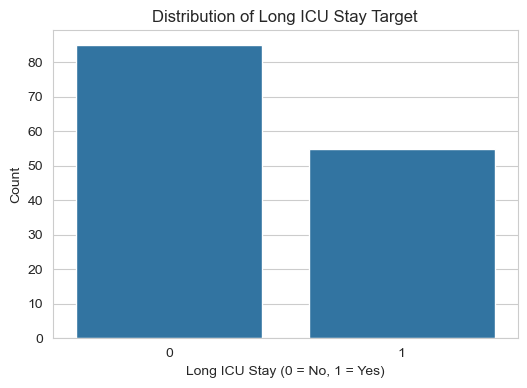

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(data=final_df, x="long_icu_stay")
plt.title("Distribution of Long ICU Stay Target")
plt.xlabel("Long ICU Stay (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

#  ICU LOS distribution

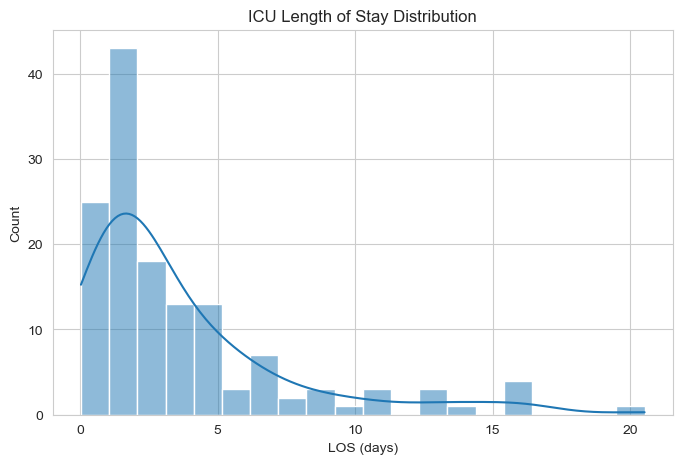

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(df["los"].dropna(), bins=20, kde=True)
plt.title("ICU Length of Stay Distribution")
plt.xlabel("LOS (days)")
plt.ylabel("Count")
plt.show()

# Age by target

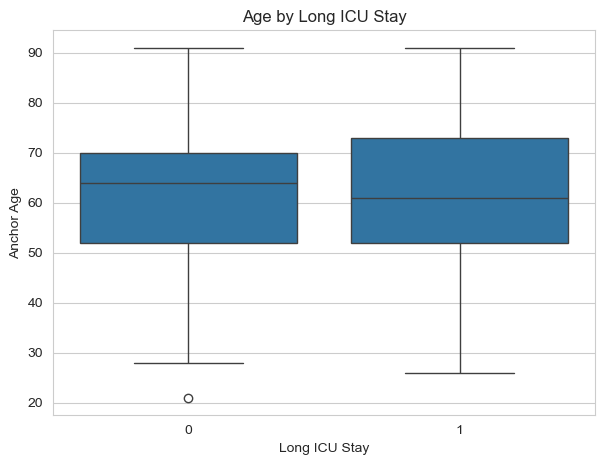

In [21]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=final_df, x="long_icu_stay", y="anchor_age")
plt.title("Age by Long ICU Stay")
plt.xlabel("Long ICU Stay")
plt.ylabel("Anchor Age")
plt.show()

# Care unit counts

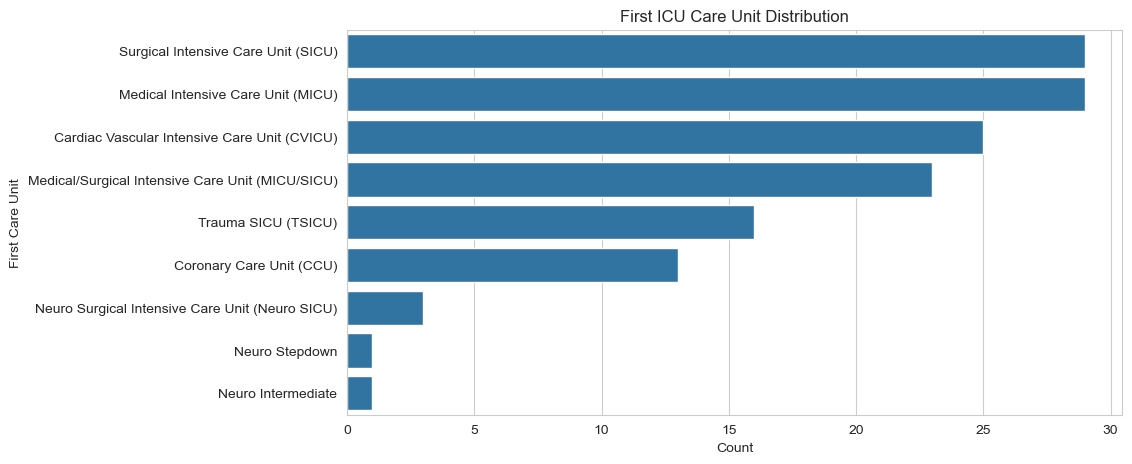

In [22]:
plt.figure(figsize=(10, 5))
order = final_df["first_careunit"].value_counts().index
sns.countplot(data=final_df, y="first_careunit", order=order)
plt.title("First ICU Care Unit Distribution")
plt.xlabel("Count")
plt.ylabel("First Care Unit")
plt.show()

# Build X and y

In [23]:
X = final_df.drop(columns=["stay_id", "subject_id", "hadm_id", "long_icu_stay"])
y = final_df["long_icu_stay"]

X = pd.get_dummies(X, drop_first=True)

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(X_imputed.shape)
X_imputed.head()

(140, 72)


,anchor_age,hospital_expire_flag,max_dbp,max_heart_rate,max_mbp,max_resp_rate,max_sbp,max_spo2,max_temperature_c,mean_dbp,mean_heart_rate,mean_mbp,mean_resp_rate,mean_sbp,mean_spo2,mean_temperature_c,min_dbp,min_heart_rate,min_mbp,min_resp_rate,min_sbp,min_spo2,min_temperature_c,first_careunit_Coronary Care Unit (CCU),first_careunit_Medical Intensive Care Unit (MICU),first_careunit_Medical/Surgical Intensive Care Unit (MICU/SICU),first_careunit_Neuro Intermediate,first_careunit_Neuro Stepdown,first_careunit_Neuro Surgical Intensive Care Unit (Neuro SICU),first_careunit_Surgical Intensive Care Unit (SICU),first_careunit_Trauma SICU (TSICU),last_careunit_Coronary Care Unit (CCU),last_careunit_Medical Intensive Care Unit (MICU),last_careunit_Medical/Surgical Intensive Care Unit (MICU/SICU),last_careunit_Neuro Intermediate,last_careunit_Neuro Stepdown,last_careunit_Neuro Surgical Intensive Care Unit (Neuro SICU),last_careunit_Surgical Intensive Care Unit (SICU),last_careunit_Trauma SICU (TSICU),gender_M,admission_type_ELECTIVE,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT,admission_location_EMERGENCY ROOM,admission_location_INFORMATION NOT AVAILABLE,admission_location_PACU,admission_location_PHYSICIAN REFERRAL,admission_location_PROCEDURE SITE,admission_location_TRANSFER FROM HOSPITAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,insurance_Medicare,insurance_Other,language_ENGLISH,marital_status_MARRIED,marital_status_SINGLE,marital_status_Unknown,marital_status_WIDOWED,race_BLACK/CAPE VERDEAN,race_HISPANIC OR LATINO,race_HISPANIC/LATINO - CUBAN,race_HISPANIC/LATINO - PUERTO RICAN,race_HISPANIC/LATINO - SALVADORAN,race_OTHER,race_PATIENT DECLINED TO ANSWER,race_PORTUGUESE,race_UNABLE TO OBTAIN,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - OTHER EUROPEAN
0,83.0,0.0,68.0,93.0,83.0,26.0,136.0,100.0,37.1,54.642857,76.040000,73.500000,20.560000,115.857143,95.920000,36.407143,49.0,65.0,68.0,13.0,108.0,91.0,35.5,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,63.0,0.0,78.0,92.0,86.0,21.0,130.0,98.0,37.1,68.857143,74.880000,79.714286,16.560000,117.142857,96.160000,36.407143,58.0,60.0,72.0,13.0,108.0,93.0,35.5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,63.0,0.0,102.0,78.0,107.0,18.0,128.0,100.0,37.1,81.000000,62.600000,93.400000,14.611111,120.000000,95.562500,36.407143,71.0,55.0,85.0,9.0,112.0,94.0,35.5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,91.0,0.0,64.0,78.0,79.0,29.0,164.0,97.0,37.1,41.916667,67.920000,67.833333,22.307692,144.375000,92.920000,36.407143,31.0,57.0,58.0,15.0,127.0,88.0,35.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,56.0,0.0,78.0,96.0,89.0,25.0,130.0,100.0,37.1,57.366667,87.454545,67.100000,20.058824,100.100000,96.764706,36.407143,43.0,74.0,53.0,14.0,77.0,93.0,35.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train model
# A random forest is a practical first baseline for tabular predictive modeling on mixed clinical features

In [26]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6, n_estimators=200,
                       random_state=42)

# Evaluate model

In [27]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7142857142857143
ROC AUC: 0.7914438502673797

Confusion Matrix:
[[11  6]
 [ 2  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.65      0.73        17
           1       0.60      0.82      0.69        11

    accuracy                           0.71        28
   macro avg       0.72      0.73      0.71        28
weighted avg       0.75      0.71      0.72        28



#  Confusion matrix

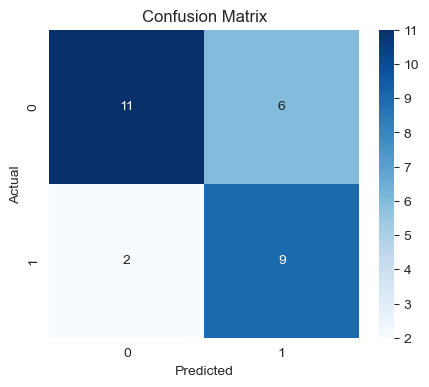

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  ROC curve

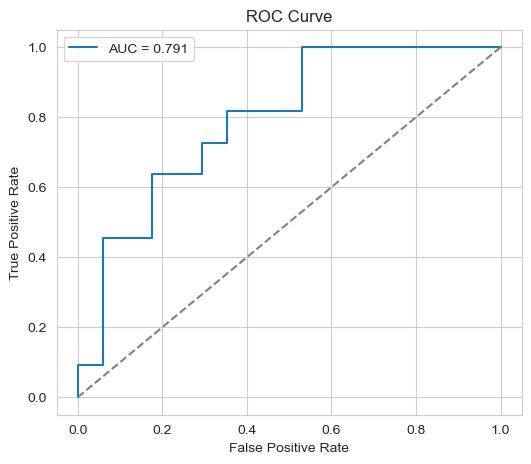

In [29]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#  Feature importance

In [30]:
feature_importance = pd.DataFrame({
    "feature": X_imputed.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
3,max_heart_rate,0.071752
10,mean_heart_rate,0.071525
12,mean_resp_rate,0.055436
20,min_sbp,0.051835
18,min_mbp,0.045098
14,mean_spo2,0.044116
6,max_sbp,0.043011
0,anchor_age,0.041040
17,min_heart_rate,0.040674
9,mean_dbp,0.038519


# Top feature importance

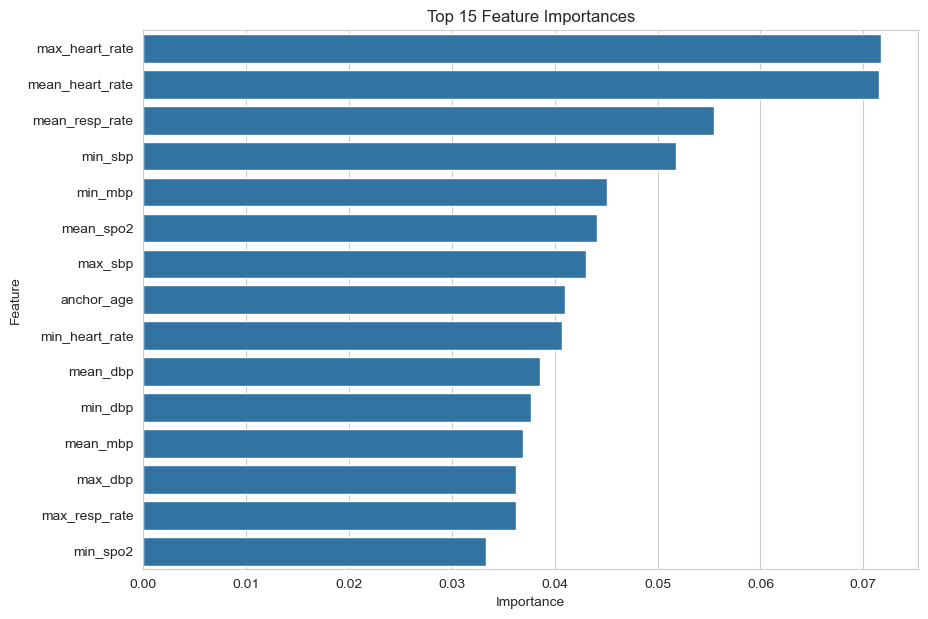

In [31]:
top_n = 15
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 7))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Correlation heatmap for vitals


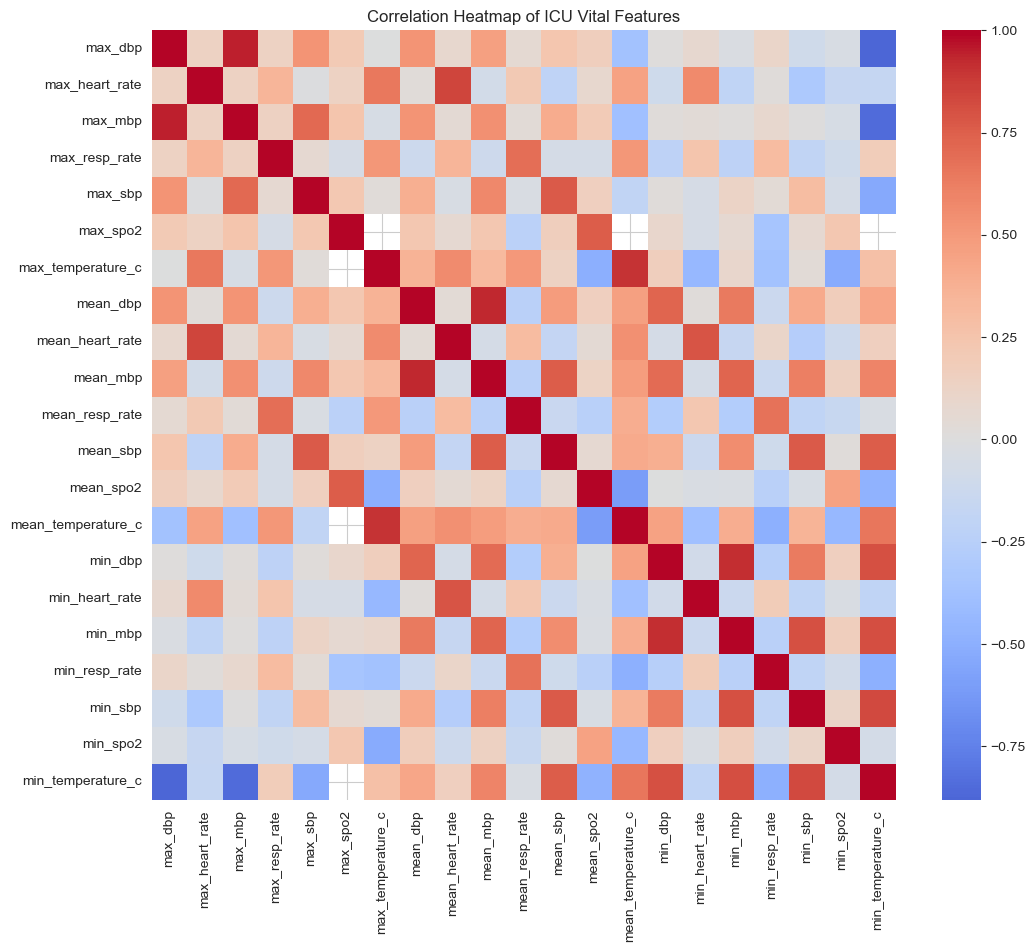

In [32]:
vital_corr_cols = [col for col in final_df.columns if any(
    col.startswith(prefix) for prefix in ["mean_", "min_", "max_"]
)]

corr_df = final_df[vital_corr_cols].copy()
corr_df = corr_df.apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of ICU Vital Features")
plt.show()

# Interpretation after visualizations
The exploratory visualizations and model evaluation provide an initial understanding of the ICU prediction task. The target distribution, LOS distribution, and care-unit breakdown help describe the structure of the cohort, while the confusion matrix, ROC curve, and feature-importance plot show how the baseline random forest is performing on the long ICU stay prediction problem.

The feature-importance plot suggests that the model is using clinically relevant information from demographic, admission, and early ICU vital-sign features. If variables such as age, heart rate, respiratory rate, oxygen saturation, blood pressure, or ICU care unit appear among the top predictors, this supports the idea that the model is learning meaningful patterns from critical-care data rather than relying only on arbitrary correlations

However, standard feature importance has a limitation: it tells us which variables matter overall, but it does not explain how each feature pushes an individual prediction toward a long ICU stay or a shorter ICU stay. For a healthcare application, this distinction is important because clinicians need not only predictive performance, but also interpretable reasoning that can support trust and reduce cognitive burden in decision-making

To address this limitation, the next step is to apply SHAP explainability. SHAP will provide both global explanations, showing which features are influential across the full cohort, and local explanations, showing why the model made a specific prediction for an individual ICU stay.

## SHAP Explainability

In this section, SHAP is used to interpret the trained random forest model. The goal is to move beyond model accuracy and examine how specific features contribute to predictions at both the population and individual-patient level.

The visual analysis shows how the data are distributed and how the baseline model performs, but it does not fully explain why the model made its predictions. Global feature importance gives only a partial view. Therefore, the next step is to use SHAP to generate both global and local explanations, which better align with the project’s focus on explainability, trust, and cognitive support in healthcare AI.

In [33]:
!pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [34]:
import shap
import matplotlib.pyplot as plt

In [35]:
explainer = shap.TreeExplainer(model)

In [36]:
shap_values_raw = explainer.shap_values(X_test)
type(shap_values_raw)

numpy.ndarray

In [37]:
import numpy as np

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

elif hasattr(shap_values_raw, "values"):
    vals = shap_values_raw.values
    if vals.ndim == 3:
        shap_values = vals[:, :, 1]
        base_value = shap_values_raw.base_values[:, 1] if np.array(shap_values_raw.base_values).ndim > 1 else shap_values_raw.base_values
    else:
        shap_values = vals
        base_value = shap_values_raw.base_values

else:
    if np.array(shap_values_raw).ndim == 3:
        shap_values = shap_values_raw[:, :, 1]
        base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    else:
        shap_values = shap_values_raw
        base_value = explainer.expected_value

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (28, 72)


# SHAP bar plot

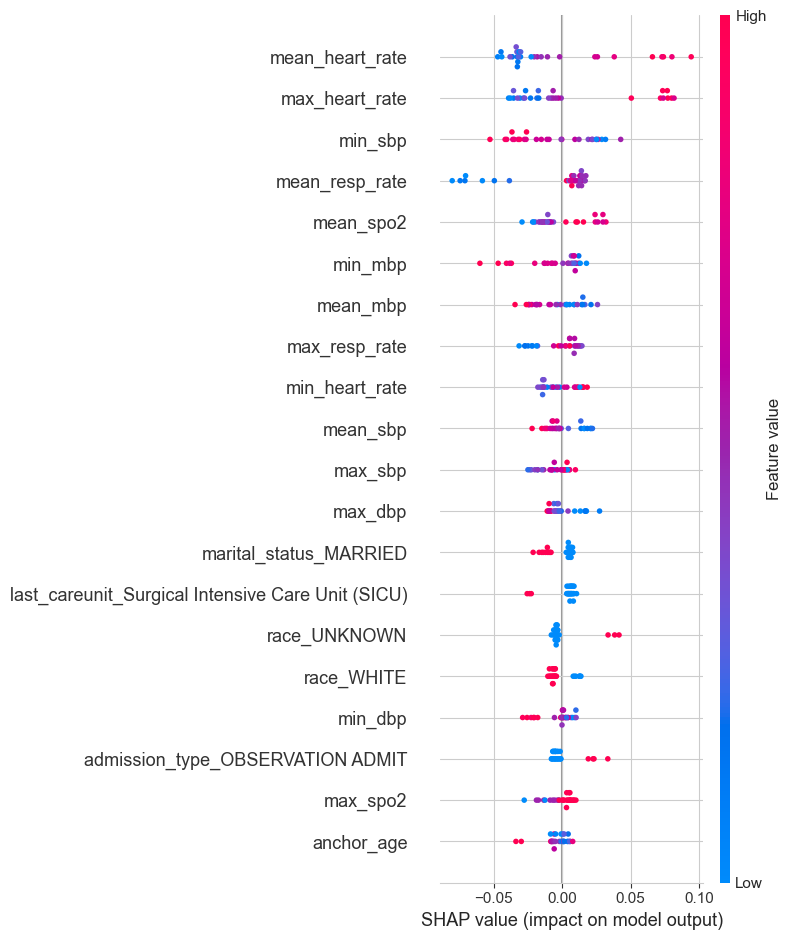

In [38]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False, max_display=20)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Create a SHAP Explanation object for local plots

In [39]:
if np.array(base_value).ndim == 0:
    base_vals_for_expl = np.repeat(base_value, X_test.shape[0])
else:
    base_vals_for_expl = np.array(base_value)

shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=base_vals_for_expl,
    data=X_test.values,
    feature_names=X_test.columns.tolist()
)

In [40]:
patient_index = 0
X_test.iloc[[patient_index]]

,anchor_age,hospital_expire_flag,max_dbp,max_heart_rate,max_mbp,max_resp_rate,max_sbp,max_spo2,max_temperature_c,mean_dbp,mean_heart_rate,mean_mbp,mean_resp_rate,mean_sbp,mean_spo2,mean_temperature_c,min_dbp,min_heart_rate,min_mbp,min_resp_rate,min_sbp,min_spo2,min_temperature_c,first_careunit_Coronary Care Unit (CCU),first_careunit_Medical Intensive Care Unit (MICU),first_careunit_Medical/Surgical Intensive Care Unit (MICU/SICU),first_careunit_Neuro Intermediate,first_careunit_Neuro Stepdown,first_careunit_Neuro Surgical Intensive Care Unit (Neuro SICU),first_careunit_Surgical Intensive Care Unit (SICU),first_careunit_Trauma SICU (TSICU),last_careunit_Coronary Care Unit (CCU),last_careunit_Medical Intensive Care Unit (MICU),last_careunit_Medical/Surgical Intensive Care Unit (MICU/SICU),last_careunit_Neuro Intermediate,last_careunit_Neuro Stepdown,last_careunit_Neuro Surgical Intensive Care Unit (Neuro SICU),last_careunit_Surgical Intensive Care Unit (SICU),last_careunit_Trauma SICU (TSICU),gender_M,admission_type_ELECTIVE,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT,admission_location_EMERGENCY ROOM,admission_location_INFORMATION NOT AVAILABLE,admission_location_PACU,admission_location_PHYSICIAN REFERRAL,admission_location_PROCEDURE SITE,admission_location_TRANSFER FROM HOSPITAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,insurance_Medicare,insurance_Other,language_ENGLISH,marital_status_MARRIED,marital_status_SINGLE,marital_status_Unknown,marital_status_WIDOWED,race_BLACK/CAPE VERDEAN,race_HISPANIC OR LATINO,race_HISPANIC/LATINO - CUBAN,race_HISPANIC/LATINO - PUERTO RICAN,race_HISPANIC/LATINO - SALVADORAN,race_OTHER,race_PATIENT DECLINED TO ANSWER,race_PORTUGUESE,race_UNABLE TO OBTAIN,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - OTHER EUROPEAN
116,78.0,0.0,97.0,145.0,101.0,40.0,123.0,99.0,37.1,72.857143,129.909091,80.0,23.863636,103.047619,97.136364,36.407143,59.0,96.0,67.0,15.0,88.0,93.0,35.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


#  Waterfall plot for one prediction

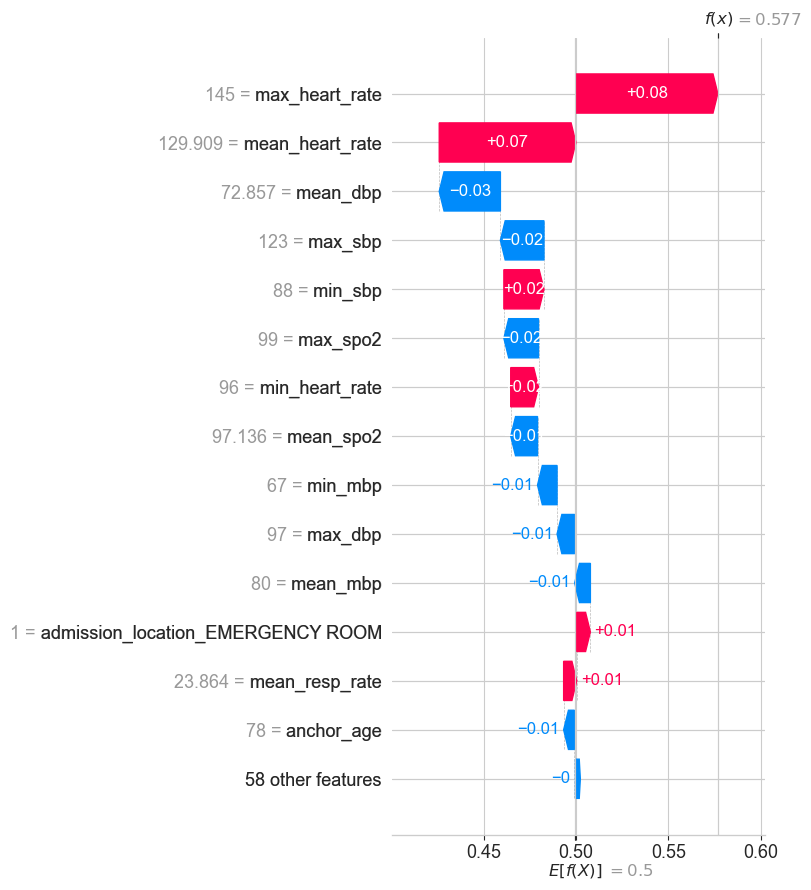

In [41]:
plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_explanation[patient_index], max_display=15, show=False)
plt.tight_layout()
plt.savefig("shap_waterfall_patient0.png", dpi=300, bbox_inches="tight")
plt.show()

# Force plot for one prediction

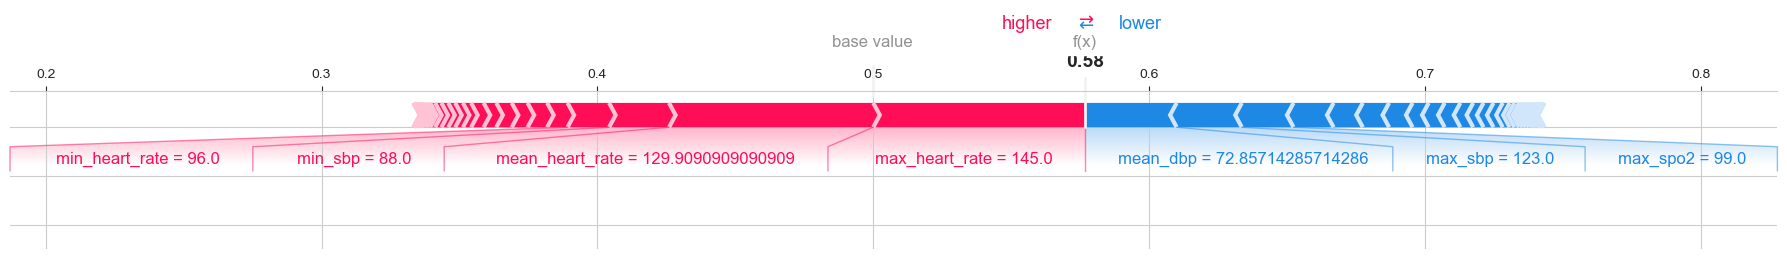

In [42]:
shap.force_plot(
    base_value=shap_explanation[patient_index].base_values,
    shap_values=shap_explanation[patient_index].values,
    features=X_test.iloc[patient_index],
    matplotlib=True,
    show=False,
    figsize=(18, 3)
)

plt.tight_layout()
plt.savefig("shap_force_patient0.png", dpi=300, bbox_inches="tight")
plt.show()

# Dependence plot for a top feature

In [43]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature = X_test.columns[np.argmax(mean_abs_shap)]
print("Top SHAP feature:", top_feature)

Top SHAP feature: mean_heart_rate


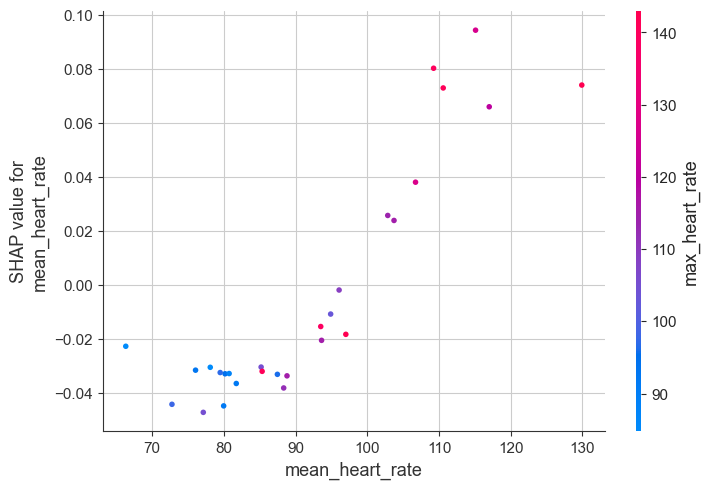

In [44]:
shap.dependence_plot(
    top_feature,
    shap_values,
    X_test,
    show=False
)
plt.tight_layout()
plt.savefig("shap_dependence_top_feature.png", dpi=300, bbox_inches="tight")
plt.show()

#  Top SHAP values table

In [45]:
shap_importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(15)

,feature,mean_abs_shap
10,mean_heart_rate,0.037954
3,max_heart_rate,0.035490
20,min_sbp,0.025197
12,mean_resp_rate,0.024103
14,mean_spo2,0.016519
18,min_mbp,0.015740
11,mean_mbp,0.014512
5,max_resp_rate,0.012568
17,min_heart_rate,0.011053
13,mean_sbp,0.010099


In [46]:
shap_importance.to_csv("shap_feature_importance.csv", index=False)

# SHAP interpretation
SHAP provides a more detailed explanation of the random forest model than standard feature importance alone. The summary plot shows which variables have the largest overall influence on predictions, while the waterfall and force plots explain how specific features push an individual ICU stay prediction toward a longer or shorter stay.

This is important for healthcare AI because predictive performance alone is not sufficient in high-stakes settings. By showing how age, admission factors, care unit, and early vital signs influence model outputs, SHAP supports the kind of transparency, trust, and reduced cognitive burden that the project proposal emphasizes.